## Example 2:
Example workflow that trains a CNN to predict the amplitude and phase aberration coefficients from a z-stack,
using synthetic examples generated from the forwards model on-the-fly as training data.

In [1]:
import logging
import warnings

import torch
import pytorch_lightning as pl
from lightning_fabric.utilities.warnings import PossibleUserWarning

In [2]:
# Silence a few nuisance warnings:
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=PossibleUserWarning)
warnings.filterwarnings("ignore", message="Starting from v1.9.0, `tensorboardX`")
warnings.filterwarnings("ignore", message=r".*isinstance\(treespec, LeafSpec\).*")

In [3]:
from cynosure.config import SimulationConfig, OpticalConfig, PriorConfig, ZernikeConfig, NoiseConfig
from cynosure.utilities.visualization import (
    format_zernike_names,
    plot_stack,
    plot_correlation_matrix,
    plot_coefficient_uncertainties,
)
from cynosure.zstack_decoding import (
    ZstackSolver,
    ZstackSolver_Heteroscedastic,
    ZstackSolver_Covariance,
    make_object_distribution,
)

#### Simulation setup

In [4]:
# Simulation parameters:
pupil_grid_size = 255
object_grid_size = 31
object_pixel_size = 0.1  # um
rng_seed = 123

# Experimental parameters:
wavelength = 0.510  # um
focal_length = 4.50e3  # um
numerical_aperture = 0.9
medium_index = 1.54
immersion_index = 1.0
dz = 0.5  # um, physical objective z-step
bead_diameter = 0.1  # um

# Fitting parameters:
max_phase_order = 6  # max Zernike N
max_amplitude_order = 4  # max Zernike N
num_z = 7  # number of z-slices to fit, ~centered around the focal plane

device = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
sim_cfg = SimulationConfig(
    pupil_grid_size=pupil_grid_size,
    object_grid_size=object_grid_size,
    object_pixel_size=object_pixel_size,
    ftype=torch.float32,
    ctype=torch.complex64,
)
opt_cfg = OpticalConfig(
    wavelength=wavelength,
    focal_length=focal_length,
    numerical_aperture=numerical_aperture,
    aperture_type="fitted",
    medium_index=medium_index,
    immersion_index=immersion_index,
)
phase_cfg = ZernikeConfig(
    max_phase_order,
    allowed_nm=(
        (1, 1), (1, -1),
        (2, -2), (2, 0), (2, 2),
        (3, -3), (3, -1), (3, 1), (3, 3),
        (4, -4), (4, -2), (4, 0), (4, 2), (4, 4),
        (5, -5), (5, -3), (5, -1), (5, 1), (5, 3), (5, 5),
    )
)
amp_cfg = ZernikeConfig(
    max_amplitude_order,
    allowed_nm=(
        (0, 0),
        (1, 1), (1, -1),
        (2, -2), (2, 0), (2, 2),
        (3, -1), (3, 1),
        (4, 0),
    )
)
noise_cfg = NoiseConfig(
    min_photons=100_000,
    max_photons=1_000_000,
    max_background=1_000,
    read_noise=10,
)

In [6]:
z = torch.arange(-(num_z//2), num_z//2 + 1).float() * dz
object_distrib = make_object_distribution(sim_cfg.object_grid_size, sim_cfg.object_pixel_size, bead_diameter)
phase_prior = PriorConfig(0.05, 1)
amp_prior = PriorConfig(0.05, 2)

#### Solver setup and training

In [7]:
pl.seed_everything(rng_seed, workers=True)
solver = ZstackSolver_Covariance(
    sim_cfg=sim_cfg,
    optics_cfg=opt_cfg,
    phase_cfg=phase_cfg,
    amp_cfg=amp_cfg,
    phase_prior_cfg=phase_prior,
    amp_prior_cfg=amp_prior,
    z_objective=z,
    object_distribution=object_distrib,
    noise_cfg=noise_cfg,
    learning_rate=1e-3,
    weight_decay=1e-3,
    generator_chunk=16
)
solver = solver.to(device)

Seed set to 123


In [8]:
trainer = pl.Trainer(
    max_epochs=15,
    accelerator=device,
    log_every_n_steps=50,
)
trainer.fit(solver)

Sanity Checking: |                                                                  | 0/? [00:00<?, ?it/s]

Training: |                                                                         | 0/? [00:00<?, ?it/s]

Validation: |                                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                                       | 0/? [00:00<?, ?it/s]

...

Validation: |                                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                                       | 0/? [00:00<?, ?it/s]

#### Sanity checking the results

In [9]:
batch_size = 4
images, phase_coefs, amp_coefs = solver.create_examples(batch_size)
pred_phase_coefs, pred_amp_coefs = solver.predict_coefficients(images)

pred_images = solver.simulate_normalized_stacks(pred_phase_coefs, pred_amp_coefs)

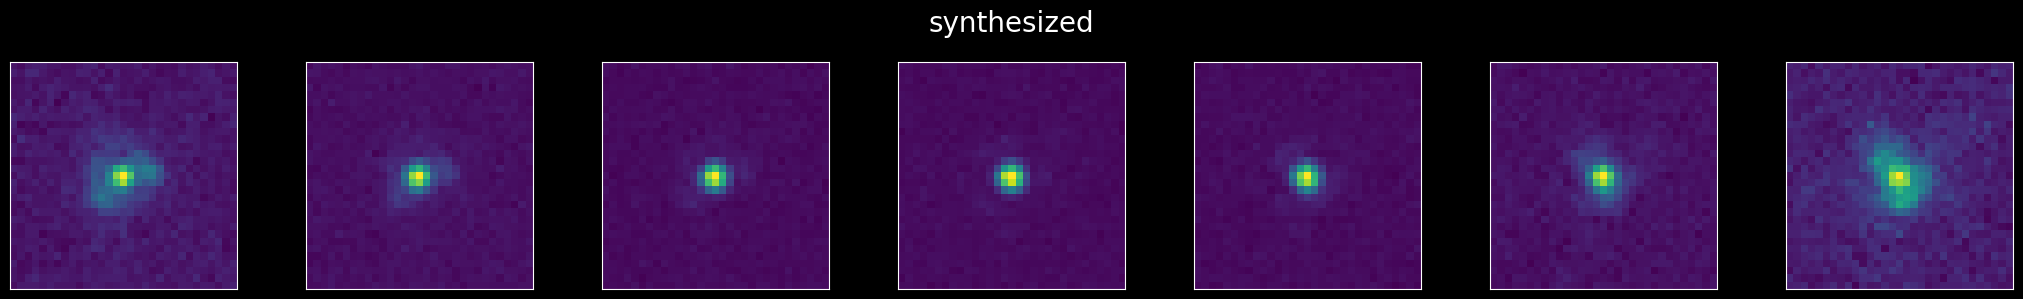

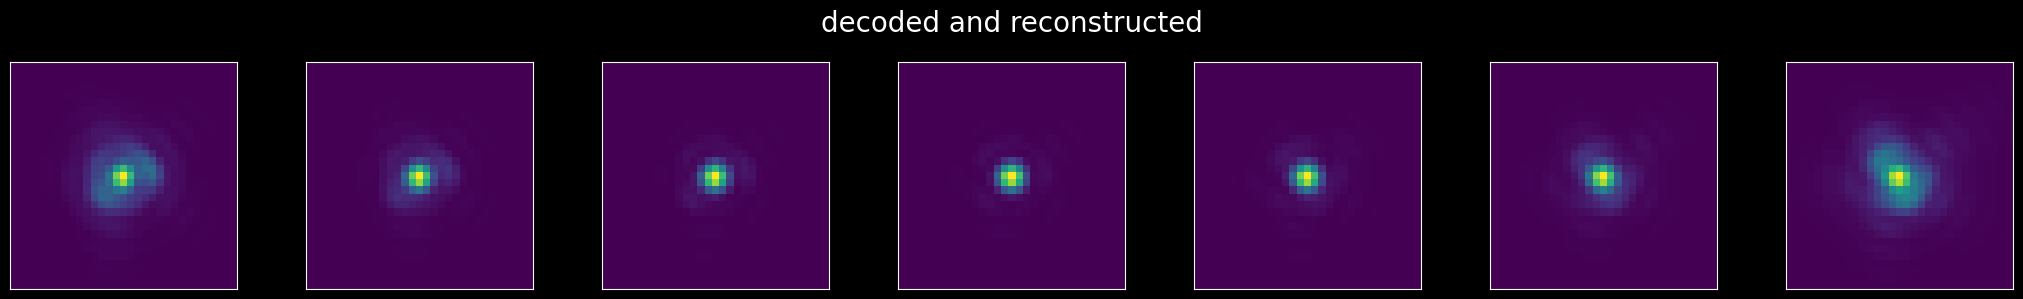

In [10]:
bidx = 0

fig1 = plot_stack(images.numpy(force=True)[bidx])
fig1.suptitle("synthesized", size=20)
fig1.tight_layout()

fig2 = plot_stack(pred_images.numpy(force=True)[bidx])
fig2.suptitle("decoded and reconstructed", size=20)
fig2.tight_layout()


#### Visualizing the predicted covariances

In [11]:
images, phase_coefs, amp_coefs = solver.create_examples(256)
dist = solver.predict_distribution(images)

In [12]:
nm_labels = format_zernike_names(solver.propagator.phase_projector.nm_indices, "Z")
nm_labels += format_zernike_names(solver.propagator.phase_projector.nm_indices, "A")

kept_labels = [label for label, piston in zip(nm_labels, solver.is_piston.tolist()) if not piston]
num_kept_phase = int((~solver.is_phase_piston).sum())

covariances = dist.covariance_matrix
sigmas = covariances.diagonal(dim1=-2, dim2=-1).sqrt()
correlations = covariances / (sigmas.unsqueeze(-1) * sigmas.unsqueeze(-2))

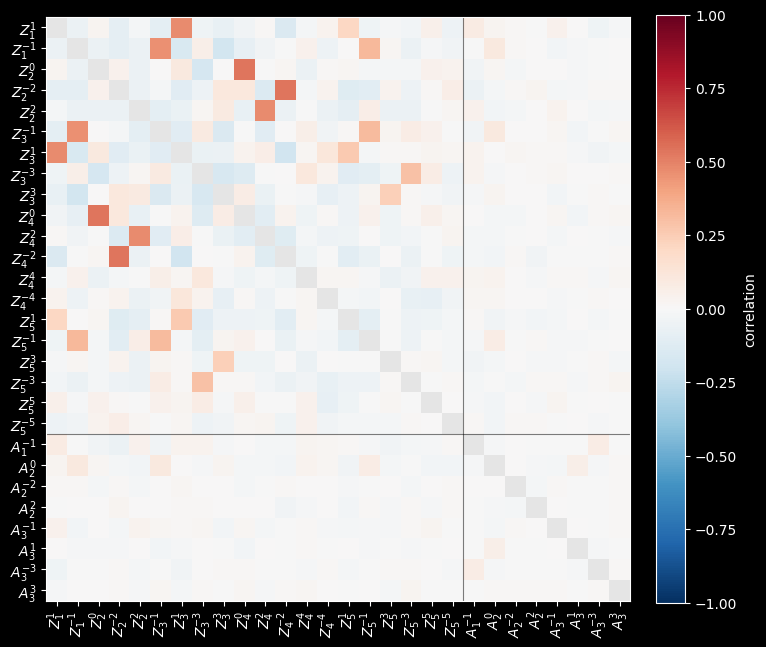

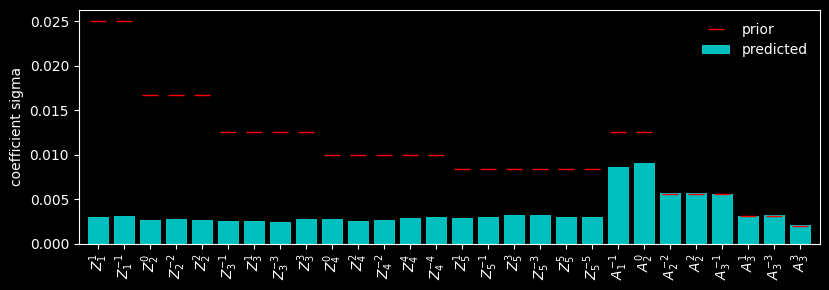

In [13]:
fig3 = plot_correlation_matrix(correlations.mean(0).numpy(force=True), kept_labels, num_phase=num_kept_phase)

prior_sigmas = solver.target_scales[~solver.is_piston]
fig4 = plot_coefficient_uncertainties(
    sigmas.mean(0).numpy(force=True),
    prior_sigmas.numpy(force=True),
    kept_labels,
)